# **Sales Analysis**

In [2]:
import pandas as pd
import numpy
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

In [4]:
sales_df = pd.read_csv(
    'dataset/processed/ecommerce_processed.csv',
    parse_dates=['order_date']
)

In [5]:
sales_df.sample(10)

,order_date,order_year,order_month,order_day_of_week,part_day,is_weekend,customer_name,gender,age,age_group,customer_segment,country,order_status,category,sub_category,unit_price_usd,price_tier,quantity,quantity_segment,gross_revenue_usd,discount_amount_usd,discount_percent,discount_tier,is_discounted,revenue_usd,order_value_segment,profit_usd,profit_margin_percent,payment_method,shipping_method,shipping_cost_usd,shipping_cost_percent,delivery_days,delivery_speed,shipping_country,shipment_type,rating,customer_loyalty_score,loyalty_tier,coupon_used,session_duration_min,engagement_level,pages_visited,abandoned_cart_before,fraud_risk_score,fraud_risk_level,device_type,campaign_source,traffic_source
764106,2025-10-12 07:12:16.460769,2025,10,Sun,Morning,Yes,Bradley Parker,Male,48,45-54,VIP,Australia,Processing,Home,Furniture,31.95,Budget,4,Bulk,127.80,6.39,5,Low Discount,Yes,121.41,Medium,61.93,51.01,PayPal,Express,22.84,18.81,6,Standard,Australia,Domestic,1,8.30,Low,No,39.40,Medium,11,Yes,27.70,Low,Mobile,Google Ads,Email
474476,2024-11-13 23:01:32.570249,2024,11,Wed,Evening,No,Justin Mejia,Male,71,65+,Premium,United States,Completed,Sports,Outdoor,240.95,Luxury,5,Bulk,"1,204.75",0.00,0,No Discount,No,"1,204.75",Very High,547.85,45.47,PayPal,Economy,11.81,0.98,5,Standard,United States,Domestic,2,82.50,High,Yes,57.40,High,10,No,53.90,Medium,Tablet,Google Ads,Social
757588,2024-05-13 16:36:00.585785,2024,5,Mon,Afternoon,No,David Thomas,Male,47,45-54,Regular,Belgium,Completed,Health,Personal Care,79.49,Mid-Range,1,Single,79.49,0.00,0,No Discount,No,79.49,Low,45.18,56.84,PayPal,Economy,8.36,10.52,10,Slow,Belgium,Domestic,4,36.00,Medium,Yes,45.90,High,5,No,87.30,High,Mobile,Google Ads,Referral
915843,2025-04-17 18:11:45.145242,2025,4,Thu,Evening,No,Brandon Harrison,Male,69,65+,Premium,Canada,Pending,Home,Appliances,198.78,Premium,2,Small Basket,397.56,79.51,20,Medium Discount,Yes,318.05,High,141.75,44.57,Apple Pay,Standard,11.45,3.60,12,Slow,Canada,Domestic,5,79.80,High,No,48.30,High,14,No,43.00,Medium,Tablet,Affiliate,Social
773550,2026-01-24 20:19:26.209625,2026,1,Sat,Evening,Yes,Jay Beasley,Male,28,25-34,Regular,Netherlands,Completed,Electronics,Tablets,219.61,Luxury,1,Single,219.61,32.94,15,Medium Discount,Yes,186.67,Medium,73.85,39.56,PayPal,Economy,12.94,6.93,10,Slow,Netherlands,Domestic,4,0.40,Low,No,32.60,Medium,1,Yes,34.10,Medium,Desktop,Affiliate,Search
304795,2025-05-04 18:24:45.785272,2025,5,Sun,Evening,Yes,Christopher Wallace,Male,59,55-64,VIP,France,Processing,Sports,Accessories,59.99,Mid-Range,2,Small Basket,119.98,6.00,5,Low Discount,Yes,113.98,Medium,40.12,35.20,Bank Transfer,Next Day,24.52,21.51,5,Standard,France,Domestic,1,5.60,Low,No,28.30,Medium,9,No,91.20,High,Desktop,Organic,Search
54799,2025-07-01 00:37:56.730822,2025,7,Tue,Night,No,Joshua Garrison MD,Male,34,25-34,Premium,France,Completed,Home,Bedding,165.42,Premium,4,Bulk,661.68,0.00,0,No Discount,No,661.68,Very High,232.12,35.08,PayPal,Standard,5.05,0.76,1,Fast,France,Domestic,3,41.20,Medium,Yes,3.50,Low,7,Yes,6.40,Low,Mobile,Organic,Email
876304,2025-08-19 22:41:11.886182,2025,8,Tue,Evening,No,Cindy Mcclain,Female,47,45-54,Regular,Canada,Completed,Sports,Outdoor,105.46,Premium,4,Bulk,421.84,42.18,10,Low Discount,Yes,379.66,High,159.34,41.97,Debit Card,Express,13.74,3.62,3,Fast,Canada,Domestic,1,48.60,Medium,No,28.90,Medium,17,Yes,47.50,Medium,Desktop,Facebook,Search
393804,2024-11-08 20:58:10.418201,2024,11,Fri,Evening,No,Tanya Bowman,Female,31,25-34,Premium,Canada,Completed,Clothing,Womens Wear,48.26,Budget,4,Bulk,193.04,19.30,10,Low Discount,Yes,173.74,Medium,62.94,36.23,Bank Transfer,Economy,0.71,0.41,12,Slow,Canada,Domestic,5,66.80,Medium,Yes,21.90,Medium,15,No,69.00,Medium,Tablet,Organic,Email
44941,2024-04-19 00:50:15.125786,2024,4,Fri,Night,No,Adam Jones,Male,37,35-44,Premium,Germany,Pending,Electronics,Cameras,438.18,Luxury,4,Bulk,"1,752.72",350.54,20,Medium Discount,Yes,"1,402.18",Very High,390.86,27.88,PayPal,Standard,17.46,1.25,6,Standard,Germany,

## 1.1 Revenue by Time

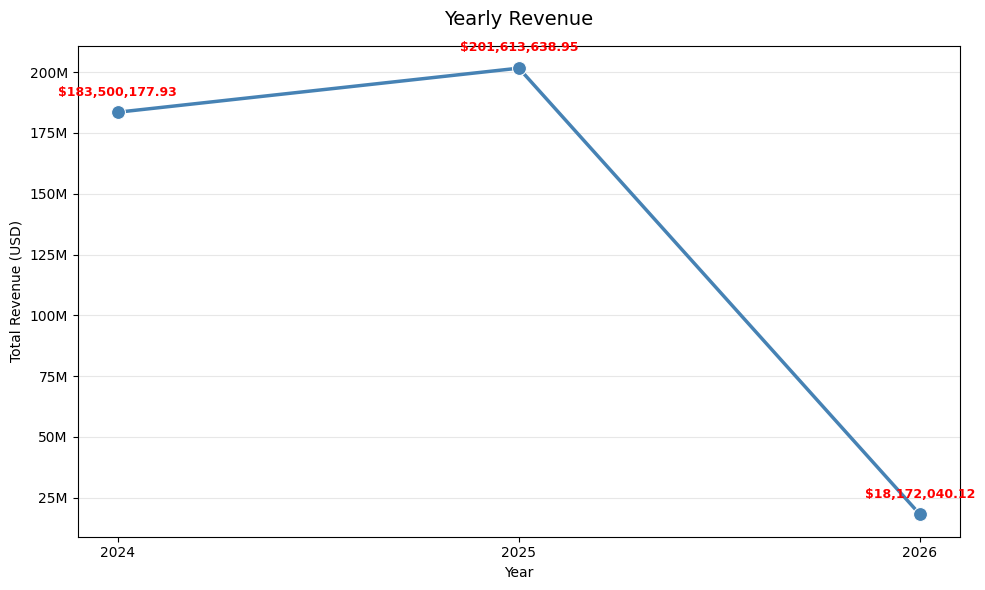

In [6]:
# 1.1.1 Yearly Revenue

yearly_revenue = (
    sales_df.groupby('order_year')['revenue_usd']
    .sum()
    .reset_index()
)

plt.figure(figsize=(10, 6))

ax = sns.lineplot(
    data=yearly_revenue,
    x='order_year',
    y='revenue_usd',
    marker='o',
    markersize=10,
    linewidth=2.5,
    color='steelblue',
)

# Add value labels on each marker
for x, y in zip(yearly_revenue['order_year'], yearly_revenue['revenue_usd']):
    ax.annotate(
        f'${y:,}',              
        (x, y),
        textcoords='offset points',
        xytext=(0, 12),
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='red'
    )

plt.title('Yearly Revenue', fontsize=14, pad=15)
plt.xlabel('Year')
plt.ylabel('Total Revenue (USD)')
plt.xticks(yearly_revenue['order_year'])
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

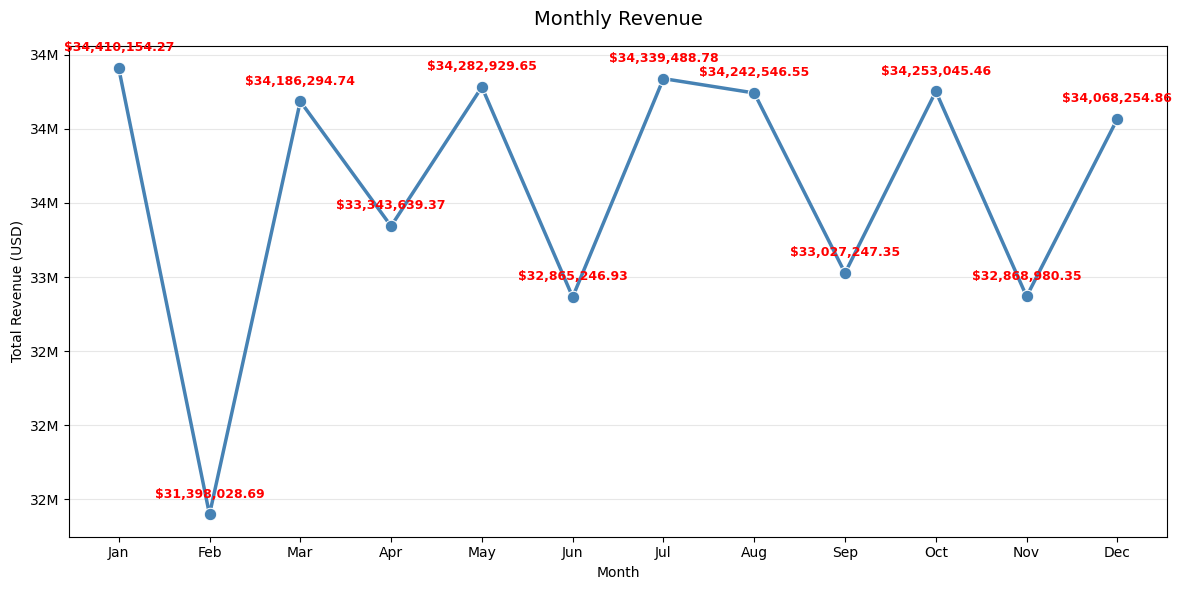

In [7]:
# 1.1.2 Monthly Revenue

month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_map = {i+1: m for i, m in enumerate(month_order)}

sales_df['order_month'] = sales_df['order_month'].map(month_map)

monthly_revenue = (
    sales_df.groupby('order_month')['revenue_usd']
    .sum()
    .reindex(month_order)
    .reset_index()
)

plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=monthly_revenue,
    x='order_month',
    y='revenue_usd',
    marker='o',
    markersize=9,
    linewidth=2.5,
    color='steelblue'
)

for x, y in zip(monthly_revenue['order_month'], monthly_revenue['revenue_usd']):
    ax.annotate(
        f'${y:,}',
        (x, y),
        textcoords='offset points',
        xytext=(0, 12),
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='red'
    )

plt.title('Monthly Revenue', fontsize=14, pad=15)
plt.xlabel('Month')
plt.ylabel('Total Revenue (USD)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

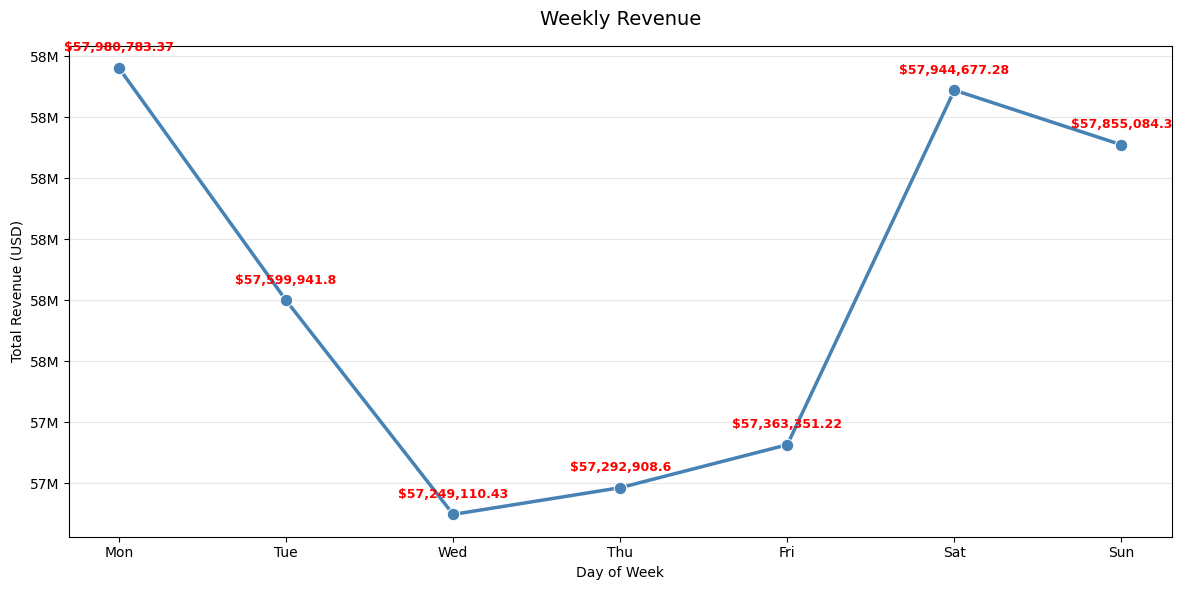

In [8]:
# 1.1.3 Day of Week Revenue

day_of_week_revenue = (
    sales_df.groupby('order_day_of_week')['revenue_usd']
    .sum()
    .reindex(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
    .reset_index()
)

plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=day_of_week_revenue,
    x='order_day_of_week',
    y='revenue_usd',
    marker='o',
    markersize=9,
    linewidth=2.5,
    color='steelblue',
)

for x, y in zip(day_of_week_revenue['order_day_of_week'], day_of_week_revenue['revenue_usd']):
    ax.annotate(
        f'${y:,}',
        (x, y),
        textcoords='offset points',
        xytext=(0, 12),
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='red'
    )

plt.title('Weekly Revenue', fontsize=14, pad=15)
plt.xlabel('Day of Week')
plt.ylabel('Total Revenue (USD)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

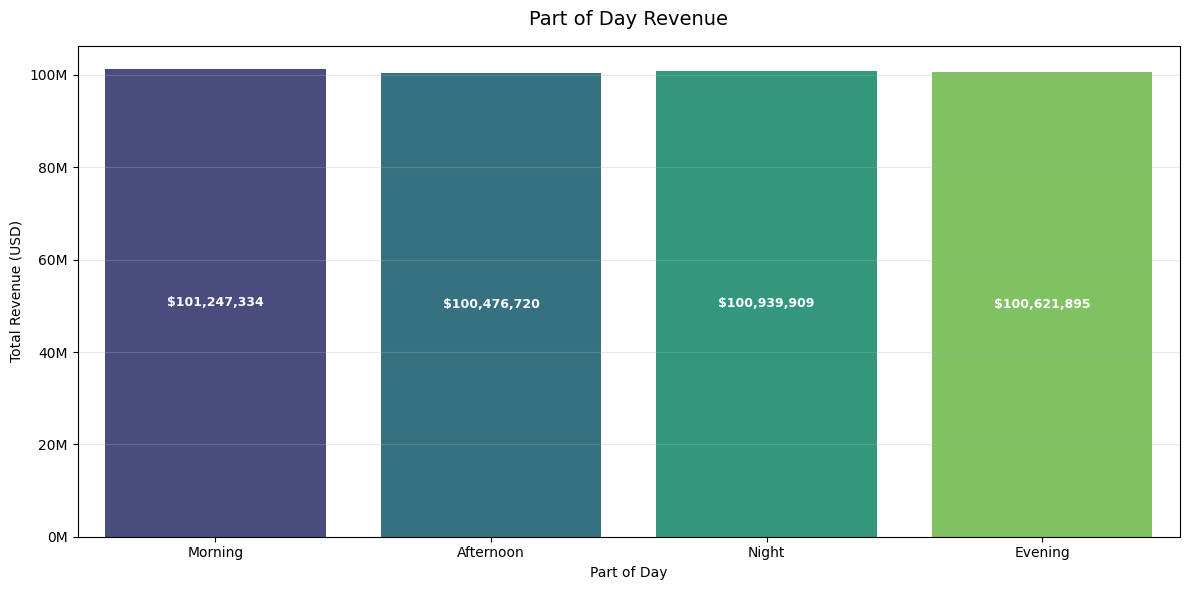

In [9]:
# 1.1.4 Part of Day Revenue

part_day_revenue = (
    sales_df.groupby('part_day')['revenue_usd']
    .sum()
    .reindex(['Morning', 'Afternoon', 'Night', 'Evening'])
    .reset_index()
)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=part_day_revenue,
    x='part_day',
    y='revenue_usd',
    palette='viridis',
    hue='part_day',
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.0f}' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=9,
        fontweight='bold'
    )

plt.title('Part of Day Revenue', fontsize=14, pad=15)
plt.xlabel('Part of Day')
plt.ylabel('Total Revenue (USD)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

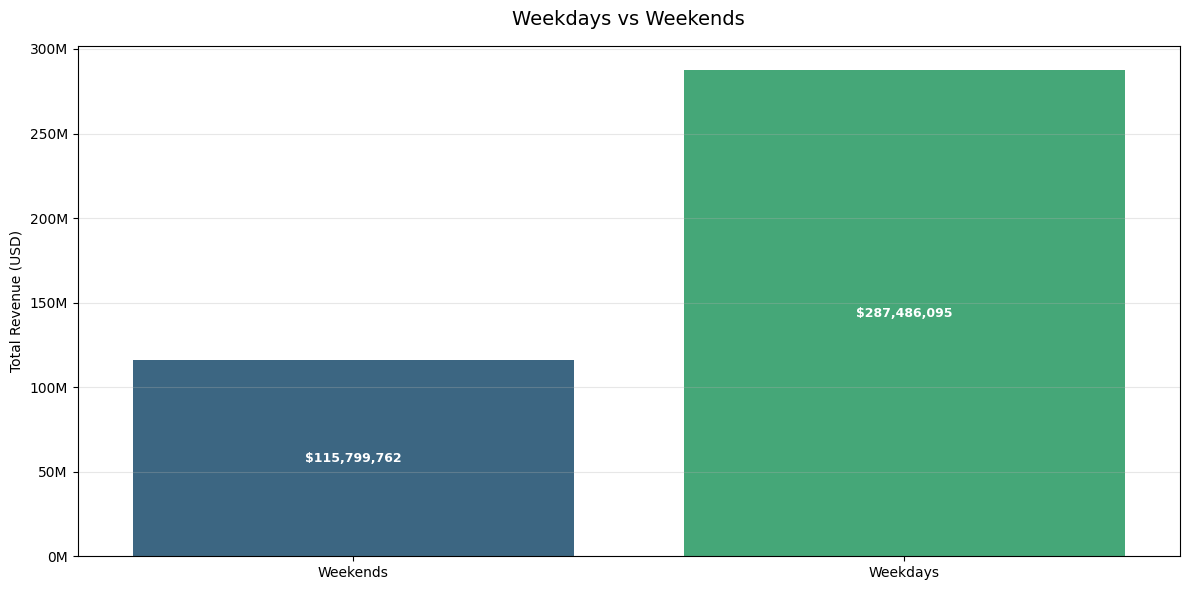

In [10]:
# 1.1.5 Weekend vs Weekedays

is_weekend_revenue = (
    sales_df.groupby('is_weekend')['revenue_usd']
    .sum()
    .reindex(['Yes', 'No'])
    .reset_index()
)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=is_weekend_revenue,
    x='is_weekend',
    y='revenue_usd',
    palette='viridis',
    hue='is_weekend',
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.0f}' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=9,
        fontweight='bold'
    )

plt.title('Weekdays vs Weekends', fontsize=14, pad=15)
plt.xlabel('')
plt.xticks([0, 1], ['Weekends', 'Weekdays'])
plt.ylabel('Total Revenue (USD)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 1.2 Revenue by Category and Sub-Category

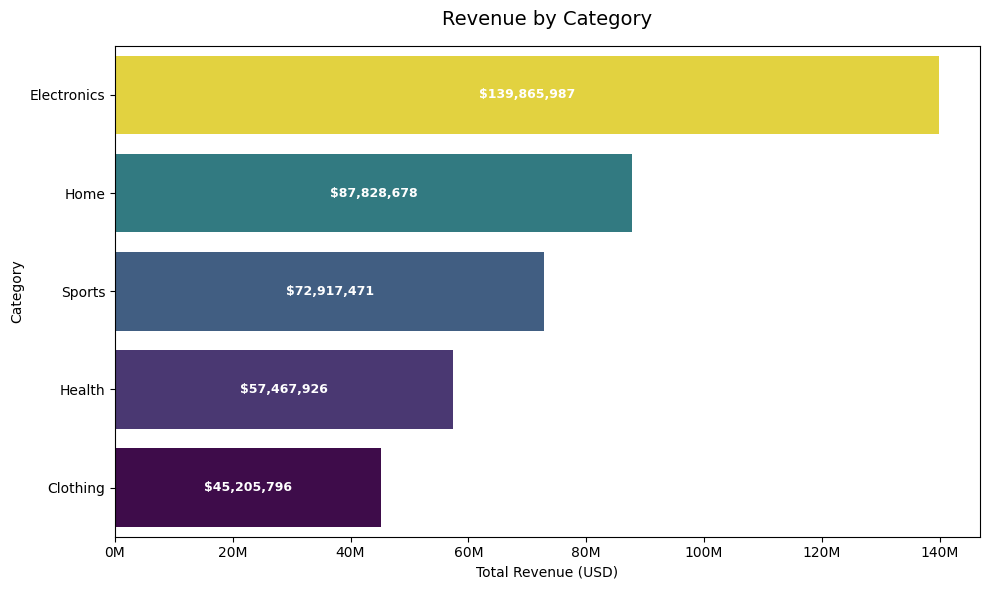

In [11]:
# 1.2.1 Revenue per Category

category_revenue = (
    sales_df.groupby('category')['revenue_usd']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=category_revenue,
    x='revenue_usd',
    y='category',
    palette='viridis',
    orient='h',
    hue='revenue_usd',
    legend=False
)


for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.0f}' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=9,
        fontweight='bold'
    )

plt.title('Revenue by Category', fontsize=14, pad=15)
plt.xlabel('Total Revenue (USD)')
plt.ylabel('Category')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.tight_layout()
plt.show()

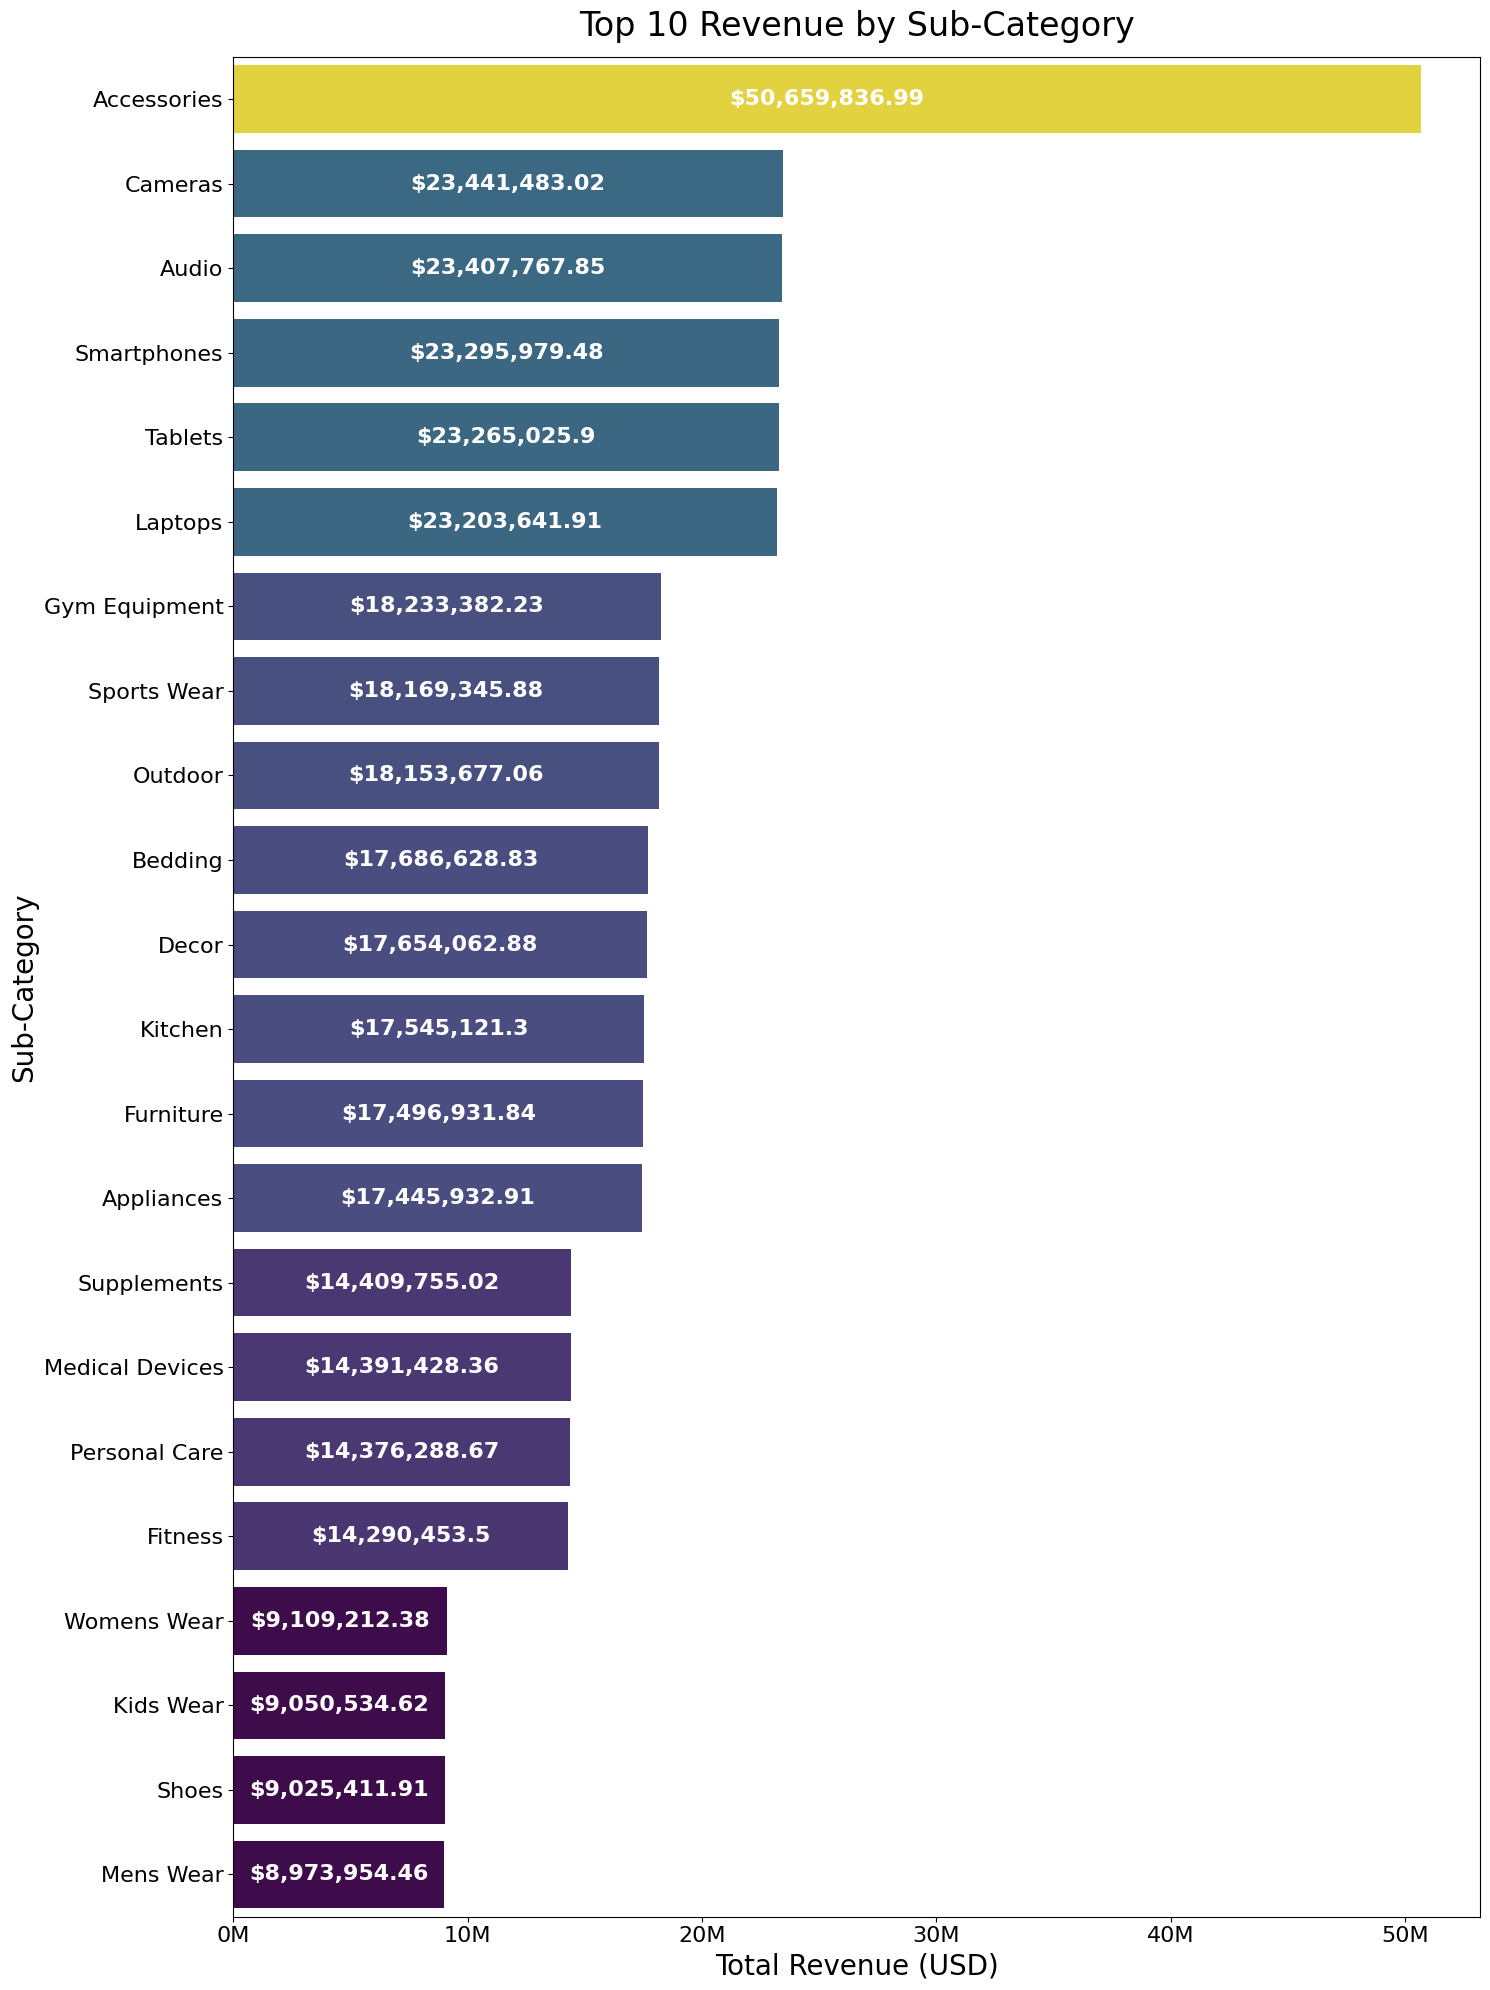

In [12]:
# 1.2.1 Top 10 Revenue Sub Category

subcategory_revenue = (
    sales_df.groupby('sub_category')['revenue_usd']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(15, 20))

ax = sns.barplot(
    data=subcategory_revenue,
    x='revenue_usd',
    y='sub_category',
    palette='viridis',
    orient='h',
    hue='revenue_usd',
    legend=False
)


for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,}' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=16,
        fontweight='bold'
    )

plt.title('Top 10 Revenue by Sub-Category', fontsize=24, pad=15)
plt.xlabel('Total Revenue (USD)', fontsize=20)
plt.ylabel('Sub-Category', fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.tight_layout()
plt.show()

## 1.3 Revenue by Country

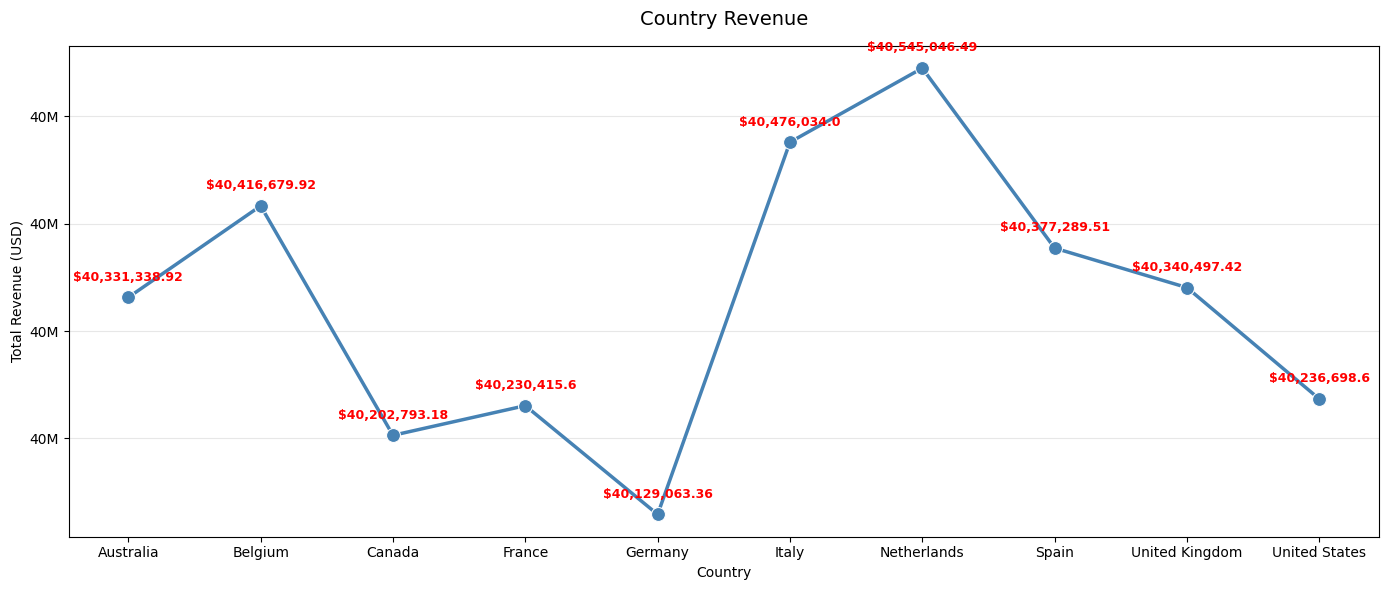

In [13]:
# 1.3.1 Country Revenue

country_revenue = (
    sales_df.groupby('country')['revenue_usd']
    .sum()
    .reset_index()
)

plt.figure(figsize=(14, 6))

ax = sns.lineplot(
    data=country_revenue,
    x='country',
    y='revenue_usd',
    marker='o',
    markersize=10,
    linewidth=2.5,
    color='steelblue',
)

# Add value labels on each marker
for x, y in zip(country_revenue['country'], country_revenue['revenue_usd']):
    ax.annotate(
        f'${y:,}',              
        (x, y),
        textcoords='offset points',
        xytext=(0, 12),
        ha='center',
        fontsize=9,
        fontweight='bold',
        color='red'
    )

plt.title('Country Revenue', fontsize=14, pad=15)
plt.xlabel('Country')
plt.ylabel('Total Revenue (USD)')
plt.xticks(country_revenue['country'])
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

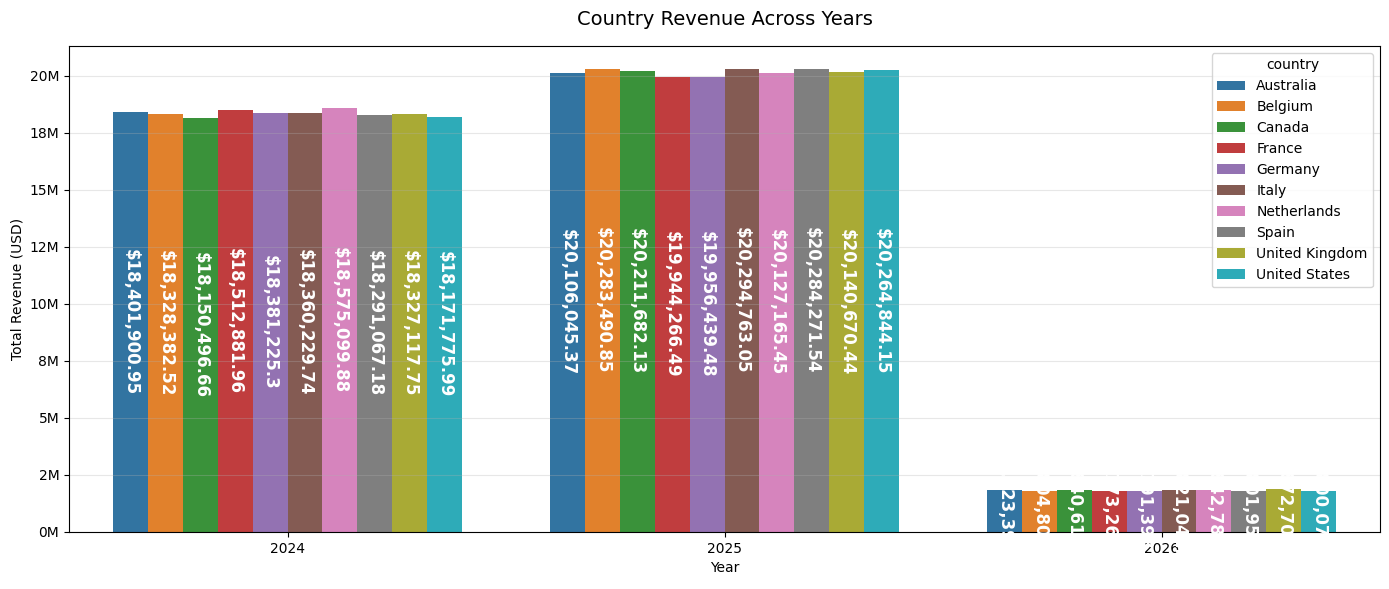

In [ ]:
# 1.3.1 Country Revenue Across Years

country_yearly_revenue = sales_df.groupby(
    ['order_year', 'country']
)['revenue_usd'].sum().reset_index()

plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=country_yearly_revenue,
    x='order_year',
    y='revenue_usd',
    palette='tab10',
    hue='country',
)


# Add value labels on each marker
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,}' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=12,
        fontweight='bold',
        rotation=-90
    )

plt.title('Country Revenue Across Years', fontsize=14, pad=15)
plt.xlabel('Year')
plt.ylabel('Total Revenue (USD)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 1.4 Revenue by Order Value Segment

C:\Users\User\AppData\Local\Temp\ipykernel_29984\2011891560.py:9: UserWarning: The palette list has more values (8) than needed (5), which may not be intended.
  ax = sns.barplot(


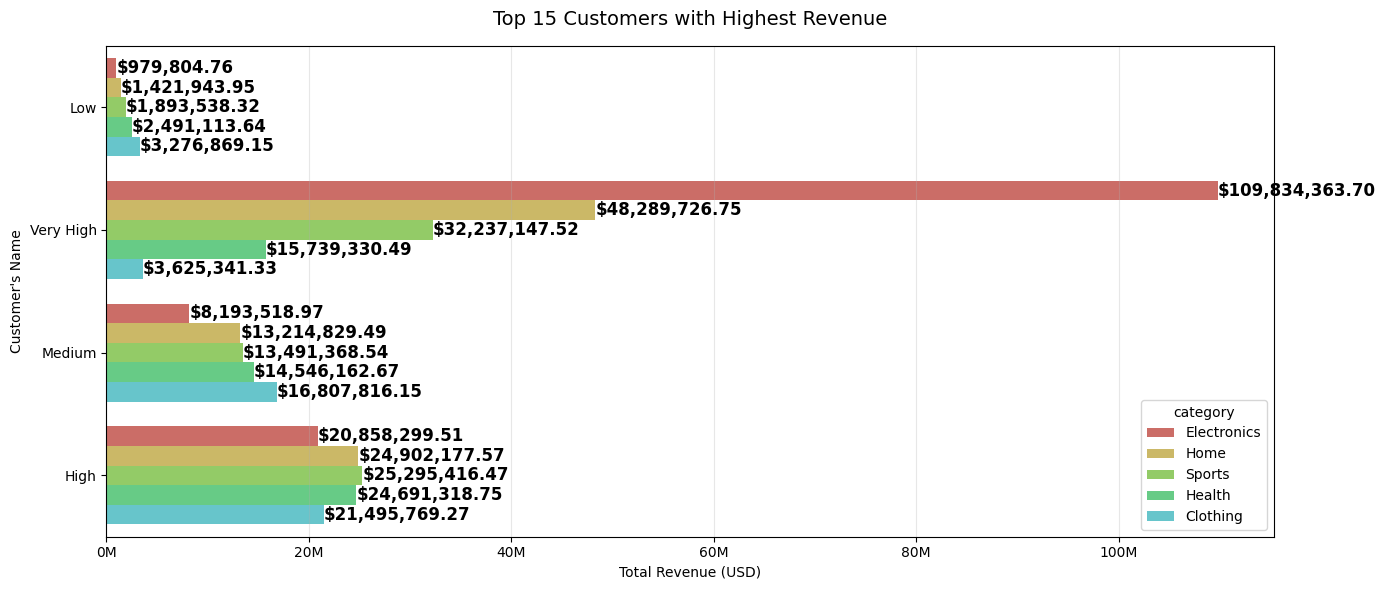

In [ ]:
# 1.4.1 Order Value Segment Revenue Across Categories

order_value_segment_revenue = sales_df.groupby(
    ['order_value_segment', 'category']
)['revenue_usd'].sum().reset_index().sort_values('revenue_usd')

plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=order_value_segment_revenue,
    x='revenue_usd',
    y='order_value_segment',
    hue='category',
    palette=sns.color_palette('hls',8)
)

# Add value labels on each marker
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.2f}' for v in container.datavalues],
        label_type='edge',          
        color='black',
        fontsize=12,
        fontweight='bold'
    )
    
plt.title('Order Value Segment Revenue Across Categories', fontsize=14, pad=15)
plt.xlabel('Total Revenue (USD)')
plt.ylabel("Order Value Segment")
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 1.5 Customers

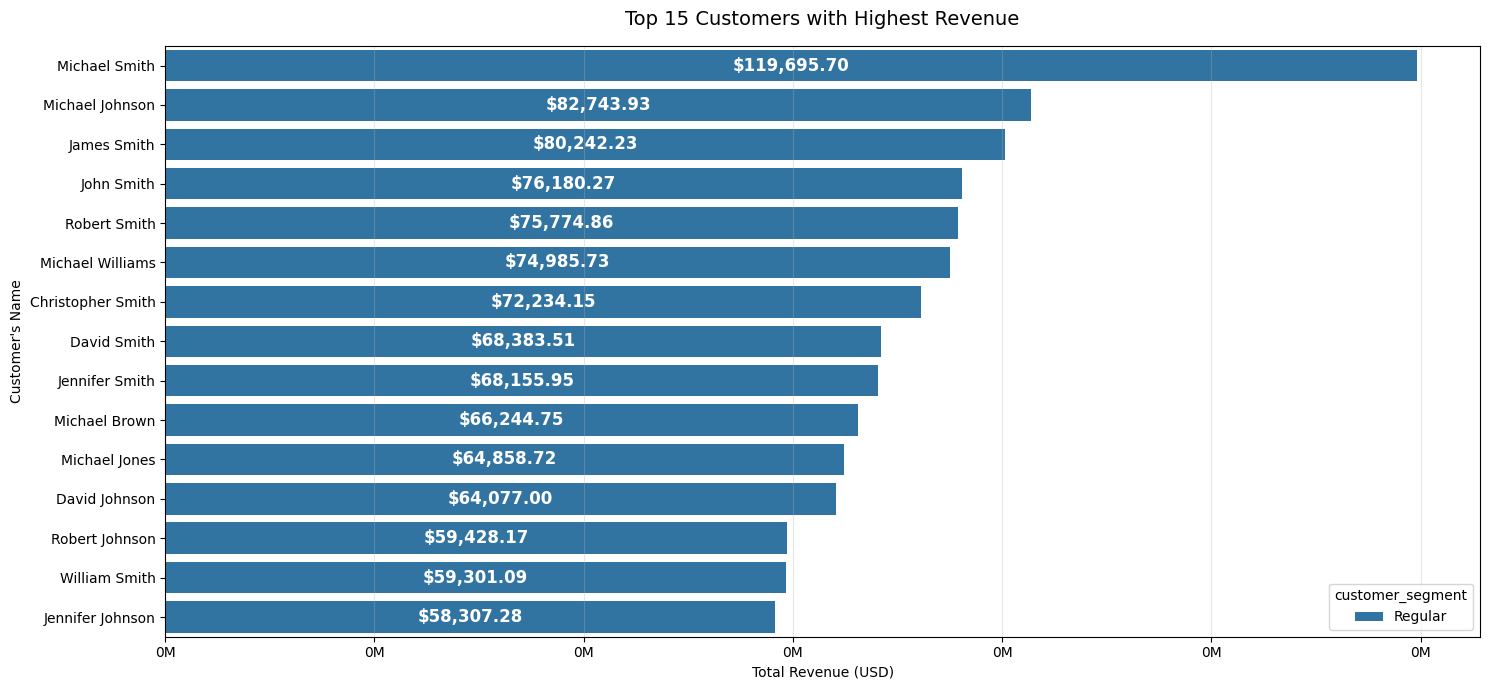

In [16]:
# 1.5.1 Top 15 Customers with Highest Revenue and their Customer Segment

customers_highest_revenue = sales_df.groupby(['customer_name','customer_segment'])['revenue_usd'].sum().reset_index().sort_values('revenue_usd', ascending=False).head(15)

plt.figure(figsize=(15, 7))

ax = sns.barplot(
    data=customers_highest_revenue,
    x='revenue_usd',
    y='customer_name',
    hue='customer_segment',
    orient='h',
    palette='tab10'
)

# Add value labels on each marker
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.2f}' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=12,
        fontweight='bold'
    )
    
plt.title('Top 15 Customers with Highest Revenue', fontsize=14, pad=15)
plt.xlabel('Total Revenue (USD)')
plt.ylabel("Customer's Name")
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

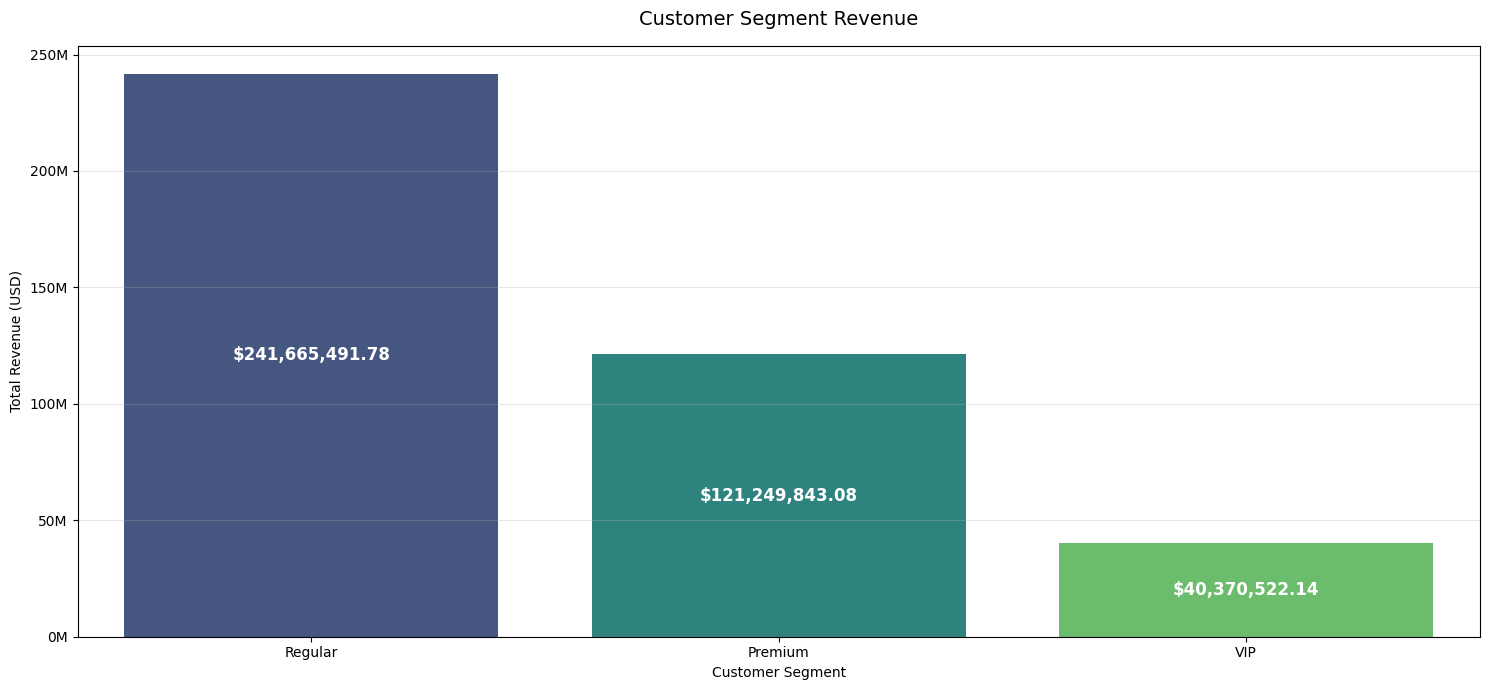

In [17]:
# 1.5.2 Customer Segment Revenue

customer_segment_revenue = sales_df.groupby('customer_segment')['revenue_usd'].sum().reset_index().sort_values('revenue_usd', ascending=False).head(15)

plt.figure(figsize=(15, 7))

ax = sns.barplot(
    data=customer_segment_revenue,
    x='customer_segment',
    y='revenue_usd',
    hue='customer_segment',
    legend=False,
    palette='viridis'
)

# Add value labels on each marker
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.2f}' for v in container.datavalues],
        label_type='center',          
        color='white',
        fontsize=12,
        fontweight='bold'
    )
    
plt.title('Customer Segment Revenue', fontsize=14, pad=15)
plt.xlabel('Customer Segment')
plt.ylabel("Total Revenue (USD)")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 1.6 Gross Revenue (Without discount) vs Revenue (With discount applied)